In [1]:
import numpy as np  # 导入数值计算库numpy
import matplotlib.pyplot as plt  # 导入绘图库matplotlib
import matplotlib.gridspec as gridspec  # 导入网格布局工具
from matplotlib import cm  # 导入颜色映射库
#可以在主图上切分出一个子图
from mpl_toolkits.axes_grid1 import make_axes_locatable  # 导入辅助轴工具
from scipy.stats import multivariate_normal  # 导入多变量正态分布
from scipy.stats import norm  # 导入正态分布

In [2]:
rho = 0.5  # 相关系数
sigma_X = 1.5  # X的标准差
sigma_Y = 1  # Y的标准差
mu_X = 0  # X的均值
mu_Y = 0  # Y的均值
mu = [mu_X, mu_Y]  # 均值向量

In [3]:
# 协方差矩阵
Sigma = [[sigma_X**2, sigma_X * sigma_Y * rho], 
         [sigma_X * sigma_Y * rho, sigma_Y**2]]  # 构建协方差矩阵

In [4]:
# 定义变量范围
width = 4  # 变量范围宽度
X = np.linspace(-width, width, 81)  # X的取值范围
Y = np.linspace(-width, width, 81)  # Y的取值范围

XX, YY = np.meshgrid(X, Y)  # 生成网格数据

XXYY = np.dstack((XX, YY))  # 组合X和Y的网格
bi_norm = multivariate_normal(mu, Sigma)  # 定义二维正态分布对象

In [5]:
y_cond_i = 60  # 选择特定的Y值索引

In [6]:
f_X_Y_joint = bi_norm.pdf(XXYY)  # 计算联合概率密度

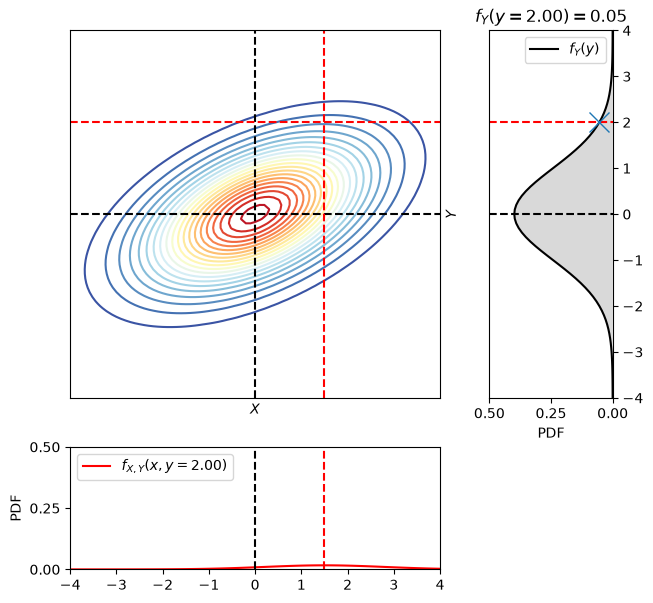

In [7]:
fig = plt.figure(figsize=(7, 7))  # 创建图形窗口
gs = gridspec.GridSpec(2, 2, width_ratios=[3, 1], height_ratios=[3, 1])  # 创建网格布局

# 左上角绘制联合分布的等高线
ax1 = plt.subplot(gs[0])  # 创建子图

# 绘制二维正态分布的等高线
ax1.contour(XX, YY, f_X_Y_joint, 20, cmap=cm.RdYlBu_r)  # 绘制等高线
ax1.axvline(x=mu_X, color='k', linestyle='--')  # X轴的均值垂直线
ax1.axhline(y=mu_Y, color='k', linestyle='--')  # Y轴的均值水平线
ax1.axhline(y=Y[y_cond_i], color='r', linestyle='--')  # 选择的Y值的水平线

x_sym_axis = mu_X + rho * sigma_X / sigma_Y * (Y[y_cond_i] - mu_Y)  # 计算X的对称轴位置
ax1.axvline(x=x_sym_axis, color='r', linestyle='--')  # 绘制X的对称轴

ax1.set_xlabel('$X$')  # 设置X轴标签
ax1.set_ylabel('$Y$')  # 设置Y轴标签
ax1.yaxis.set_label_position('right')  # 设置Y轴标签位置
ax1.set_xticks([])  # 隐藏X轴刻度
ax1.set_yticks([])  # 隐藏Y轴刻度

# 右上角绘制Y的边缘分布
ax2 = plt.subplot(gs[1])  # 创建子图
f_Y = norm.pdf(Y, loc=mu_Y, scale=sigma_Y)  # 计算Y的边缘分布

ax2.plot(f_Y, Y, 'k', label='$f_{Y}(y)$')  # 绘制Y的边缘分布
ax2.axhline(y=mu_Y, color='k', linestyle='--')  # Y的均值线
ax2.axhline(y=Y[y_cond_i], color='r', linestyle='--')  # 选择的Y值水平线
ax2.plot(f_Y[y_cond_i], Y[y_cond_i], marker='x', markersize=15)  # 绘制选择的Y值

plt.title('$f_{Y}(y_{} = %.2f) = %.2f$' % (Y[y_cond_i], f_Y[y_cond_i]))  # 设置标题

ax2.fill_between(f_Y, Y, edgecolor='none', facecolor='#D9D9D9')  # 填充边缘分布区域
ax2.legend(loc=0)  # 设置图例位置
ax2.set_xlabel('PDF')  # 设置X轴标签
ax2.set_ylim(-width, width)  # 设置Y轴范围
ax2.set_xlim(0, 0.5)  # 设置X轴范围
ax2.invert_xaxis()  # 反转X轴
ax2.yaxis.tick_right()  # Y轴刻度在右侧

# 左下角绘制联合分布的条件分布
ax3 = plt.subplot(gs[2])  # 创建子图
f_X_Y_cond_i = f_X_Y_joint[y_cond_i, :]  # 选择特定Y条件下的联合分布

ax3.plot(X, f_X_Y_cond_i, 'r', label='$f_{X,Y}(x,y_{} = %.2f)$' % (Y[y_cond_i]))  # 绘制条件分布

ax3.axvline(x=mu_X, color='k', linestyle='--')  # 绘制X的均值线
ax3.axvline(x=x_sym_axis, color='r', linestyle='--')  # 绘制X的对称轴线

ax3.legend(loc=0)  # 显示图例
ax3.set_ylabel('PDF')  # 设置Y轴标签
ax3.yaxis.set_label_position('left')  # 设置Y轴标签位置
ax3.set_xlim(-width, width)  # 设置X轴范围
ax3.set_ylim(0, 0.5)  # 设置Y轴范围
ax3.set_yticks([0, 0.25, 0.5])  # 设置Y轴刻度

ax4 = plt.subplot(gs[3])  # 创建占位子图
ax4.set_visible(False)  # 隐藏该子图

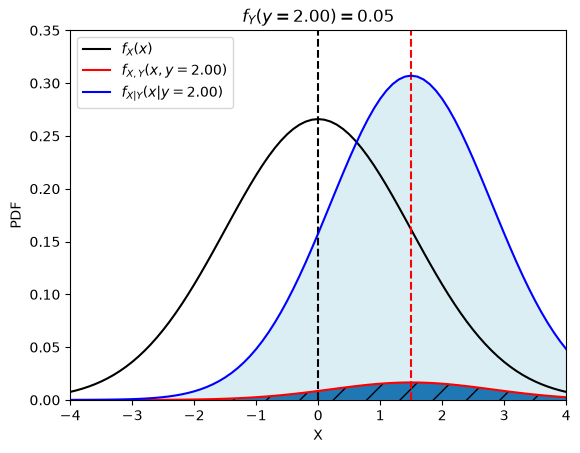

In [8]:
f_X = norm.pdf(X, loc=mu_X, scale=sigma_X)  # 计算X的边缘分布

fig, ax = plt.subplots()  # 创建图形窗口

colors = plt.cm.RdYlBu_r(np.linspace(0, 1, len(Y)))  # 定义颜色

f_X_given_Y_cond_i = f_X_Y_cond_i / f_Y[y_cond_i]  # 计算条件分布

plt.plot(X, f_X, color='k', label='$f_{X}(x)$')  # 绘制X的边缘分布
ax.axvline(x=mu_X, color='k', linestyle='--')  # 绘制X的均值线

plt.plot(X, f_X_Y_cond_i, color='r', label='$f_{X,Y}(x,y_{} = %.2f)$' % (Y[y_cond_i]))  # 绘制联合分布
ax.axvline(x=x_sym_axis, color='r', linestyle='--')  # 绘制X的对称轴线

plt.plot(X, f_X_given_Y_cond_i, color='b', label='$f_{X|Y}(x|y_{} = %.2f)$' % (Y[y_cond_i]))  # 绘制条件分布

ax.fill_between(X, f_X_given_Y_cond_i, edgecolor='none', facecolor='#DBEEF3')  # 填充条件分布区域

ax.fill_between(X, f_X_Y_cond_i, edgecolor='none', hatch='/')  # 填充联合分布区域

plt.xlabel('X')  # 设置X轴标签
plt.ylabel('PDF')  # 设置Y轴标签
ax.set_xlim(-width, width)  # 设置X轴范围
ax.set_ylim(0, 0.35)  # 设置Y轴范围
plt.title('$f_{Y}(y_{} = %.2f) = %.2f$' % (Y[y_cond_i], f_Y[y_cond_i]))  # 设置标题
ax.legend()  # 显示图例

In [10]:
a = np.array([1])
print(type(a))

<class 'numpy.ndarray'>


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm # 导入颜色映射
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import multivariate_normal
from scipy.stats import norm
from mpl_toolkits.mplot3d import axes3d

In [12]:
def fcn_Y_given_X (mu_X, mu_Y, sigma_X, sigma_Y, rho, X, Y):
    
    coeff = 1/sigma_Y/np.sqrt(1 - rho**2)/np.sqrt(2*np.pi)  # 计算系数
    sym_axis = mu_Y + rho*sigma_Y/sigma_X*(X - mu_X)  # 计算对称轴
    quad  = -1/2*((Y - sym_axis)/sigma_Y/np.sqrt(1 - rho**2))**2  # 计算指数中的二次项
    f_Y_given_X  = coeff*np.exp(quad)  # 计算条件概率密度值
    
    return f_Y_given_X

In [13]:
rho     = 0.5  # 设置相关系数
sigma_X = 1    # 设置 X 的标准差
sigma_Y = 1    # 设置 Y 的标准差

mu_X = 0  # 设置 X 的均值
mu_Y = 0  # 设置 Y 的均值

width = 3  # 设置绘图范围
X = np.linspace(-width,width,31)  # 创建 X 的线性空间
Y = np.linspace(-width,width,31)  # 创建 Y 的线性空间

XX, YY = np.meshgrid(X, Y)  # 创建网格数据

In [14]:
f_Y_given_X = fcn_Y_given_X (mu_X, mu_Y, sigma_X, sigma_Y, rho, XX, YY)  # 计算条件概率密度

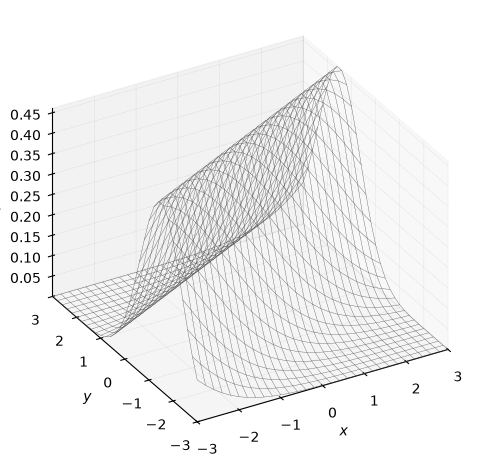

In [15]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})  # 创建3D子图

ax.plot_wireframe(XX, YY, f_Y_given_X,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制3D网格图

ax.set_xlabel('$x$')  # 设置 X 轴标签
ax.set_ylabel('$y$')  # 设置 Y 轴标签
ax.set_zlabel('$f_{Y|X}(y|x)$')  # 设置 Z 轴标签
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_Y_given_X.min(),f_Y_given_X.max())  # 设置 Z 轴范围
plt.tight_layout()  # 调整布局
ax.view_init(azim=-120, elev=30)  # 设置视角
plt.show()  # 显示图形

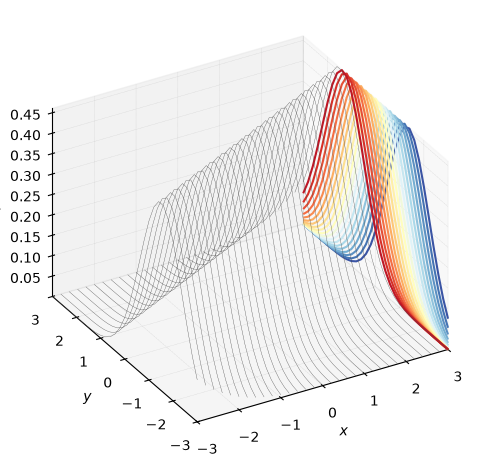

In [16]:
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_wireframe(XX, YY, f_Y_given_X, rstride=0, cstride=1,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制网格图

ax.contour(XX, YY, f_Y_given_X, 
           levels = 20, zdir='x', \
            offset=YY.max(), cmap=cm.RdYlBu_r)  # 绘制投影轮廓

ax.set_xlabel('$x$')  # 设置 X 轴标签
ax.set_ylabel('$y$')  # 设置 Y 轴标签
ax.set_zlabel('$f_{Y|X}(y|x)$')  # 设置 Z 轴标签
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_Y_given_X.min(),f_Y_given_X.max())  # 设置 Z 轴范围
plt.tight_layout()  # 调整布局
ax.view_init(azim=-120, elev=30)  # 设置视角
plt.show()  # 显示图形

In [17]:
f_Y = norm.pdf(Y, loc=mu_Y, scale=sigma_Y)  # 计算 Y 的边际分布

(0.0, 0.46065886596178074)

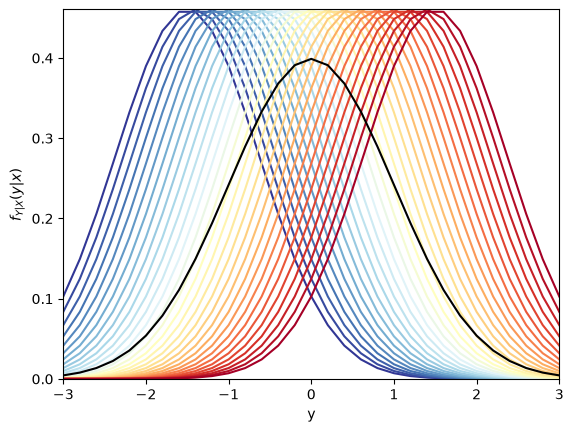

In [18]:
fig, ax = plt.subplots()  # 创建子图

colors = plt.cm.RdYlBu_r(np.linspace(0,1,len(X)))  # 设置颜色渐变

for i in np.linspace(1,len(X),len(X)):  # 遍历 X 的取值
    plt.plot(Y,f_Y_given_X[:,int(i)-1],
             color = colors[int(i)-1])  # 绘制条件分布

plt.plot(Y,f_Y, color = 'k')  # 绘制边际分布

plt.xlabel('y')  # 设置 X 轴标签
plt.ylabel('$f_{Y|X}(y|x)$')  # 设置 Y 轴标签
ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(0, f_Y_given_X.max())  # 设置 Y 轴范围

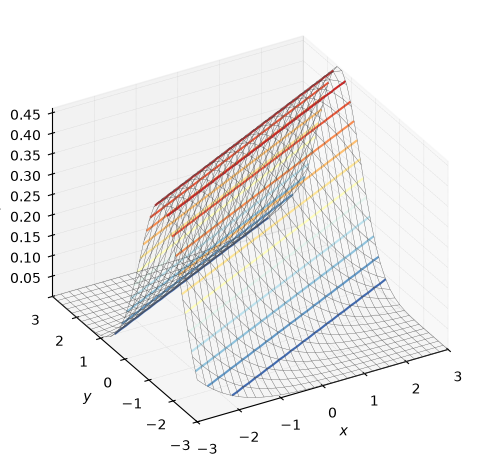

In [19]:
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_wireframe(XX, YY, f_Y_given_X,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制3D网格图

ax.contour3D(XX,YY,f_Y_given_X,12,
              cmap = 'RdYlBu_r')  # 绘制3D轮廓图

ax.set_xlabel('$x$')  # 设置 X 轴标签
ax.set_ylabel('$y$')  # 设置 Y 轴标签
ax.set_zlabel('$f_{Y|X}(y|x)$')  # 设置 Z 轴标签
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_Y_given_X.min(),f_Y_given_X.max())  # 设置 Z 轴范围
plt.tight_layout()  # 调整布局
ax.view_init(azim=-120, elev=30)  # 设置视角
plt.show()  # 显示图形

In [20]:
E_Y_given_X = mu_Y + rho*sigma_Y/sigma_X*(X - mu_X)  # 计算条件期望

Text(0, 0.5, '$y$')

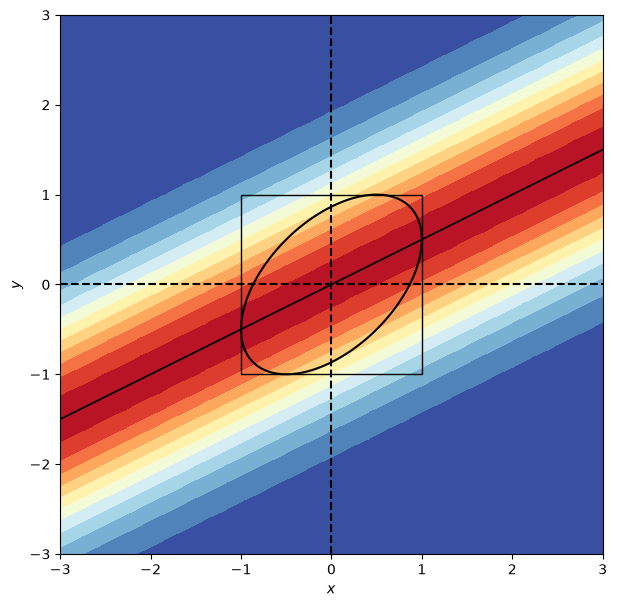

In [21]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(7, 7))  # 创建图形和坐标轴

plt.contourf(XX, YY, f_Y_given_X, 12, cmap=cm.RdYlBu_r)  # 绘制填充轮廓
plt.plot(X,E_Y_given_X, color = 'k', linewidth = 1.25)  # 绘制条件期望
plt.axvline(x = mu_X, color = 'k', linestyle = '--')  # 绘制垂直参考线
plt.axhline(y = mu_Y, color = 'k', linestyle = '--')  # 绘制水平参考线

x = np.linspace(-width,width,num = 201)  # 生成 X 坐标数据
y = np.linspace(-width,width,num = 201)  # 生成 Y 坐标数据

xx,yy = np.meshgrid(x,y);  # 创建网格

ellipse = ((xx/sigma_X)**2 - 
           2*rho*(xx/sigma_X)*(yy/sigma_Y) + 
           (yy/sigma_Y)**2)/(1 - rho**2);  # 计算等高线数据

plt.contour(xx,yy,ellipse,levels = [1], colors = 'k')  # 绘制椭圆轮廓

rect = Rectangle(xy = [- sigma_X, - sigma_Y] , 
                 width = 2*sigma_X, 
                 height = 2*sigma_Y,
                 edgecolor = 'k',facecolor="none")  # 创建矩形边界框

ax.add_patch(rect)  # 添加矩形到图形上

ax.set_xlabel('$x$')  # 设置 X 轴标签
ax.set_ylabel('$y$')  # 设置 Y 轴标签